Pandas Version: 2.2.2
SQLite3 version: 2.6.0
Dataset loaded succesfully

Task1:Average Math Score by department
      department  math_avg
Computer Science      85.6
      Mechanical      71.0
     Electronics      71.0
           Civil      63.4

Task 2: Total Number of students in each department
      department  total_students
           Civil               5
Computer Science              13
     Electronics               6
      Mechanical               6

Task 3: Top 8 students with respect to Total Score
          name  total_score
    Ananya Das          371
   Tanvi Mehta          367
Akanksha Yadav          365
    Arjun Nair          356
   Divya Singh          356
Swati Kulkarni          354
     Amit Bose          336
    Suresh Rao          334

Task 4: Average attendance by gender
gender  avg_attendance
Female            88.5
  Male            80.5


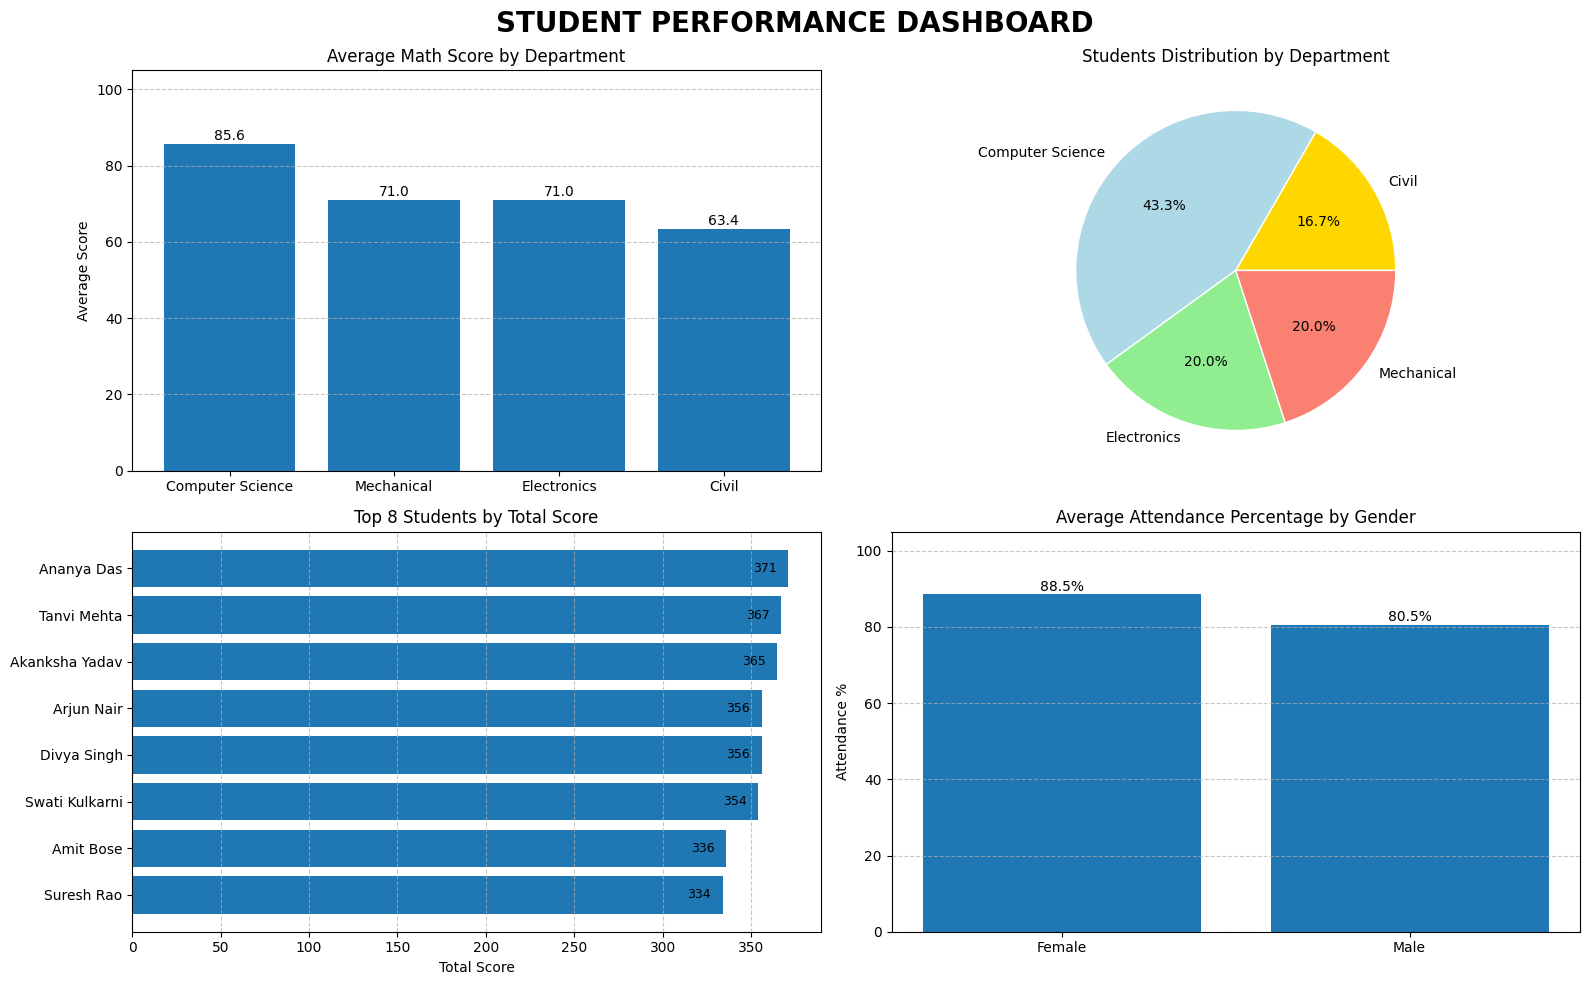


Dashboard saved successfully as 'student_dashboard.png'


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("Pandas Version:",(pd.__version__))
print("SQLite3 version:",sqlite3.version)
df=pd.read_csv('student_performance.csv')
print("Dataset loaded succesfully")

#CONNECTING TO SQLITE DATABSE
conn=sqlite3.connect('college.db')

df.to_sql('students',conn,if_exists='replace',index=False)
def run_query(sql,description=""):
  if description:
    print(f"\n{"="*55}")
    print(description)
    print(f"{"="*55}")
  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

  #Task 1
#Average Math Score by department
query1="""select department , round(avg(math_score),1) as math_avg from students
group by department order by
math_avg desc"""
result1=run_query(query1,"Task1:Average Math Score by department")


#Task 2
#total number of students in each department
query2="""select department,count(*) as total_students from students group by department"""
result2=run_query(query2,"Task 2: Total Number of students in each department")

#Task3
#Calculate total score
query3="""select name,((math_score+english_score+programming_score+science_score
))as total_score from students order by total_score desc limit 8"""
result3=run_query(query3,"Task 3: Top 8 students with respect to Total Score")

#Task 4
#Average attendance percentage by gender
query4="""select gender ,round(avg(attendance_percentage),1)as avg_attendance from students
group by gender"""
result4=run_query(query4,"Task 4: Average attendance by gender")
# ============================================
# CREATE DASHBOARD USING MATPLOTLIB
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ============================================
# PANEL 1
# Average Math Score by Department
# ============================================

ax1 = axes[0, 0]

bars1 = ax1.bar(
    result1['department'],
    result1['math_avg']
)

ax1.set_title("Average Math Score by Department")
ax1.set_ylabel("Average Score")
ax1.set_ylim(0, 105)

# Grid Lines
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Value Labels
for bar in bars1:
    height = bar.get_height()

    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}',
        ha='center',
        fontsize=10
    )

# ============================================
# PANEL 2
# Pie Chart - Students by Department
# ============================================

ax2 = axes[0, 1]

colors = ['gold', 'lightblue', 'lightgreen', 'salmon', 'violet']

ax2.pie(
    result2['total_students'],
    labels=result2['department'],
    autopct='%1.1f%%',
    colors=colors,
    wedgeprops={'edgecolor': 'white'}
)

ax2.set_title("Students Distribution by Department")

# ============================================
# PANEL 3
# Horizontal Bar Chart - Top 8 Students
# ============================================

ax3 = axes[1, 0]

# Reverse order for highest scorer at top
top_students = result3.iloc[::-1]

bars3 = ax3.barh(
    top_students['name'],
    top_students['total_score']
)

ax3.set_title("Top 8 Students by Total Score")
ax3.set_xlabel("Total Score")

# Grid Lines
ax3.grid(axis='x', linestyle='--', alpha=0.7)

# Labels inside bars
for bar in bars3:

    width = bar.get_width()

    ax3.text(
        width - 20,
        bar.get_y() + bar.get_height()/2,
        f'{width}',
        va='center',
        fontsize=9
    )

# ============================================
# PANEL 4
# Average Attendance by Gender
# ============================================

ax4 = axes[1, 1]

bars4 = ax4.bar(
    result4['gender'],
    result4['avg_attendance']
)

ax4.set_title("Average Attendance Percentage by Gender")
ax4.set_ylabel("Attendance %")
ax4.set_ylim(0, 105)

# Grid Lines
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# Percentage Labels
for bar in bars4:

    height = bar.get_height()

    ax4.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height}%',
        ha='center',
        fontsize=10
    )

# ============================================
# DASHBOARD TITLE
# ============================================

fig.suptitle(
    "STUDENT PERFORMANCE DASHBOARD",
    fontsize=20,
    fontweight='bold'
)

# Proper Spacing
plt.tight_layout()

# ============================================
# SAVE DASHBOARD
# ============================================

plt.savefig(
    "student_dashboard.png",
    dpi=150,
    bbox_inches='tight'
)

# Show Dashboard
plt.show()

# ============================================
# CONFIRMATION MESSAGE
# ============================================

print("\nDashboard saved successfully as 'student_dashboard.png'")

Pandas Version: 2.2.2
SQLite3 version: 2.6.0
Dataset loaded succesfully

Task1:Average Math Score by female students
gender  math_avg
Female     78.47

Task 2 : Example of WHERE and HAVING Clause
      department  avg_math_score
Computer Science           86.83
     Electronics           76.00
      Mechanical           72.80

Task 3 : Departments with Average Attendance Above 85%
      department  avg_attendance
Computer Science           90.69

pd.read_sql_query() executes an SQL query
and returns the result as a Pandas DataFrame.

Syntax:
pd.read_sql_query(sql_query, connection)

Arguments Required:
1. SQL Query
2. Database Connection



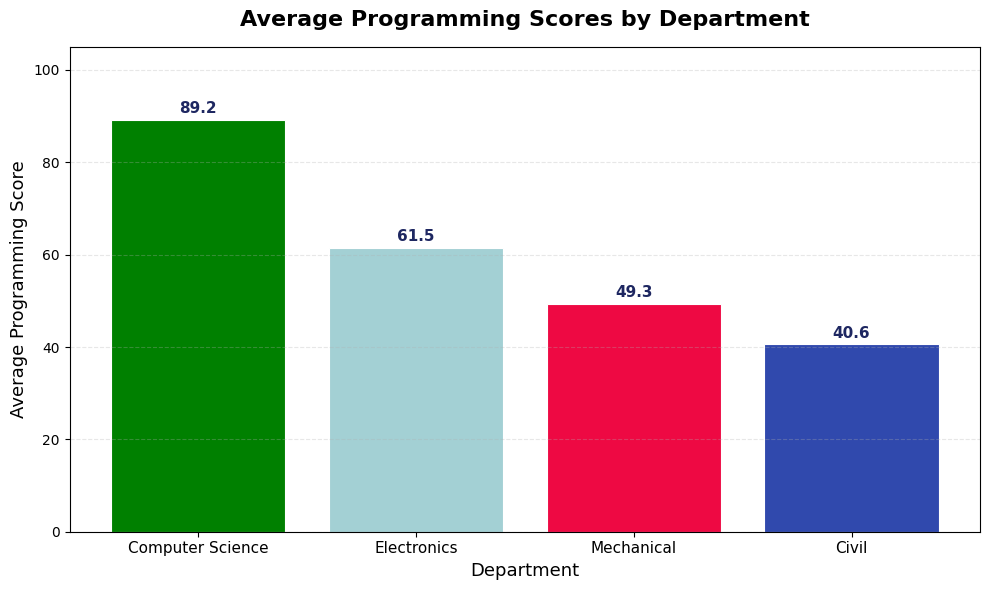

In [19]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("Pandas Version:",(pd.__version__))
print("SQLite3 version:",sqlite3.version)
df=pd.read_csv('student_performance.csv')
print("Dataset loaded succesfully")

#CONNECTING TO SQLITE DATABSE
conn=sqlite3.connect('college.db')

df.to_sql('students',conn,if_exists='replace',index=False)
def run_query(sql,description=""):
  if description:
    print(f"\n{'='*55}")
    print(description)
    print(f"{'='*55}")
  result=pd.read_sql_query(sql,conn)
  print(result.to_string(index=False))
  return result

  #Task1
query1 = """select gender, round(avg(math_score), 2) as math_avg from students where
gender = 'Female' group by  gender """
result1=run_query(query1,"Task1:Average Math Score by female students")

#Task2
query2 = """
SELECT
    department,
    ROUND(AVG(math_score), 2) AS avg_math_score
FROM students
WHERE attendance_percentage > 75
GROUP BY department
HAVING AVG(math_score) > 70
"""

result2 = run_query(
    query2,
    "Task 2 : Example of WHERE and HAVING Clause"
)

#Task3
query3 = """
SELECT
    department,
    ROUND(AVG(attendance_percentage), 2) AS avg_attendance
FROM students
GROUP BY department
HAVING AVG(attendance_percentage) > 85
"""

result3 = run_query(
    query3,
    "Task 3 : Departments with Average Attendance Above 85%"
)

#task4
print("""
pd.read_sql_query() executes an SQL query
and returns the result as a Pandas DataFrame.

Syntax:
pd.read_sql_query(sql_query, connection)

Arguments Required:
1. SQL Query
2. Database Connection
""")

#Task5
query5 = """
SELECT
    department,
    ROUND(AVG(programming_score), 2) AS avg_programming_score
FROM students
GROUP BY department
ORDER BY avg_programming_score DESC
"""

chart5_data = pd.read_sql_query(query5, conn)

# Create Figure
fig, ax = plt.subplots(figsize=(10, 6))

# Colors
bar_colors = ['#008000', '#A3D0D4', '#EE0943',
              '#3049AD', '#FFA500', '#800080']

# Bar Chart
bars = ax.bar(
    chart5_data['department'],
    chart5_data['avg_programming_score'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.8
)

# Value Labels
for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.8,
        f'{height:.1f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color='#1E2761'
    )

# Title and Labels
ax.set_title(
    'Average Programming Scores by Department',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Department', fontsize=13)
ax.set_ylabel('Average Programming Score', fontsize=13)

# Limits and Grid
ax.set_ylim(0, 105)

ax.grid(
    axis='y',
    alpha=0.3,
    linestyle='--'
)

ax.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.show()